# Análisis inicial de terrenos (scraping manual)

Este notebook hace una primera lectura del dataset limpio de terrenos y genera métricas y visualizaciones para entender su distribución.

In [1]:
from pathlib import Path

import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

pd.set_option("display.max_columns", None)
sns.set_theme(style="whitegrid", context="notebook")

In [2]:
processed_candidates = [
    Path("data/processed/scraping_manual/terrenos_idealista_clean.csv"),
    Path("../../data/processed/scraping_manual/terrenos_idealista_clean.csv")
]
csv_path = next((p for p in processed_candidates if p.exists()), None)

if csv_path is None:
    raise FileNotFoundError(
        "No se encontró terrenos_idealista_clean.csv en data/processed/scraping_manual. "
        "Ejecuta antes el notebook EDA_terreno.ipynb."
    )

df = pd.read_csv(csv_path, sep=";", encoding="utf-8")

print(f"Dataset cargado desde: {csv_path}")
print(f"Filas: {len(df):,} | Columnas: {df.shape[1]}")
df.head(3)

Dataset cargado desde: ../../data/processed/scraping_manual/terrenos_idealista_clean.csv
Filas: 1,080 | Columnas: 13


,anunciante,titulo,municipio,precio_eur,precio_anterior_eur,descuento_pct,superficie_m2,tipo_suelo,referencia_catastral,notas,vendido_con_descuento,es_urbano_o_urbanizable,precio_m2
0,Exclusivas inmobiliarias mikeli,"Barrio Llanilla, Alisal - Cazoña - San Román, ...",Santander,430000,NaN,NaN,972.0,NaN,NaN,NaN,False,False,442.386831
1,MENA INMOBILIARIA,"Oruña, Piélagos",Piélagos,139000,NaN,NaN,965.0,Urbano (solar),NaN,Edificabilidad 200 m²,False,True,144.041451
2,Grupo Inmobiliario Tribeca,"Peñacastillo - Nuevamontaña, Santander",Santander,169000,NaN,NaN,650.0,Urbano (solar),NaN,5 parcelas,False,True,260.000000


In [3]:
# Snapshot general de calidad de datos
n_registros = len(df)
n_duplicados = int(df.duplicated().sum())
pct_duplicados = round((n_duplicados / n_registros) * 100, 2) if n_registros else 0

missing = df.isna().sum().to_frame("nulos")
missing["pct_nulos"] = (missing["nulos"] / n_registros * 100).round(2) if n_registros else 0
missing = missing.sort_values("pct_nulos", ascending=False)

print(f"Registros duplicados: {n_duplicados:,} ({pct_duplicados} %)")
missing.head(15)

Registros duplicados: 17 (1.57 %)


,nulos,pct_nulos
precio_anterior_eur,1045,96.76
descuento_pct,1045,96.76
referencia_catastral,1028,95.19
notas,807,74.72
anunciante,436,40.37
tipo_suelo,38,3.52
precio_eur,0,0.00
titulo,0,0.00
municipio,0,0.00
superficie_m2,0,0.00


In [4]:
# Conversión robusta de columnas numéricas principales
numeric_candidates = [
    "precio_eur",
    "precio_anterior_eur",
    "descuento_pct",
    "superficie_m2",
    "precio_m2"
]

for col in numeric_candidates:
    if col in df.columns:
        df[col] = pd.to_numeric(df[col], errors="coerce")

if "es_urbano_o_urbanizable" in df.columns:
    df["es_urbano_o_urbanizable"] = (
        df["es_urbano_o_urbanizable"]
        .astype(str)
        .str.strip()
        .str.lower()
        .replace({"true": 1, "false": 0, "1": 1, "0": 0, "nan": np.nan})
    )
    df["es_urbano_o_urbanizable"] = pd.to_numeric(df["es_urbano_o_urbanizable"], errors="coerce")

df.dtypes

anunciante                     str
titulo                         str
municipio                      str
precio_eur                   int64
precio_anterior_eur        float64
descuento_pct              float64
superficie_m2              float64
tipo_suelo                     str
referencia_catastral           str
notas                          str
vendido_con_descuento         bool
es_urbano_o_urbanizable      int64
precio_m2                  float64
dtype: object

In [5]:
# Métricas estadísticas de variables numéricas
num_cols = [c for c in ["precio_eur", "superficie_m2", "precio_m2", "descuento_pct"] if c in df.columns]

if num_cols:
    summary = df[num_cols].describe(percentiles=[0.1, 0.25, 0.5, 0.75, 0.9]).T
    summary["iqr"] = summary["75%"] - summary["25%"]
    summary["cv"] = (summary["std"] / summary["mean"]).replace([np.inf, -np.inf], np.nan)
    display(summary)
else:
    print("No hay columnas numéricas disponibles para resumir.")

,count,mean,std,min,10%,25%,50%,75%,90%,max,iqr,cv
precio_eur,1080.0,246821.639815,330320.655220,1200.000000,45000.00000,76692.250000,140000.000000,269000.000000,560800.000000,2900000.0,192307.750000,1.338297
superficie_m2,1080.0,6580.628704,12985.475222,1.000000,688.50000,1350.000000,2934.000000,6000.000000,12896.200000,150000.0,4650.000000,1.973288
precio_m2,1080.0,137.652114,1105.667214,0.610004,6.76069,22.169811,56.322785,125.703735,230.013194,36000.0,103.533924,8.032330
descuento_pct,35.0,13.771429,12.567666,2.000000,4.40000,5.000000,10.000000,18.000000,26.000000,50.0,13.000000,0.912590


In [6]:
# Métricas por tipo de suelo
if {"tipo_suelo", "precio_eur", "superficie_m2", "precio_m2"}.issubset(df.columns):
    by_tipo = (
        df.groupby("tipo_suelo", dropna=False)
        .agg(
            n_terrenos=("tipo_suelo", "size"),
            precio_mediano=("precio_eur", "median"),
            superficie_mediana=("superficie_m2", "median"),
            precio_m2_mediano=("precio_m2", "median")
        )
        .sort_values("n_terrenos", ascending=False)
    )
    display(by_tipo)

if "es_urbano_o_urbanizable" in df.columns:
    ratio_urb = df["es_urbano_o_urbanizable"].mean(skipna=True)
    print(f"Proporción urbano/urbanizable: {ratio_urb:.2%}")

,n_terrenos,precio_mediano,superficie_mediana,precio_m2_mediano
tipo_suelo,,,,
Urbano (solar),558,180000.0,2000.0,99.064392
Urbanizable,295,125000.0,3600.0,41.489863
No urbanizable,182,59000.0,7697.0,8.999571
NaN,38,74750.0,2977.0,27.841104
Industrial,5,136850.0,7732.0,19.594122
Rústico,2,717000.0,33683.0,14.271310


Proporción urbano/urbanizable: 78.98%


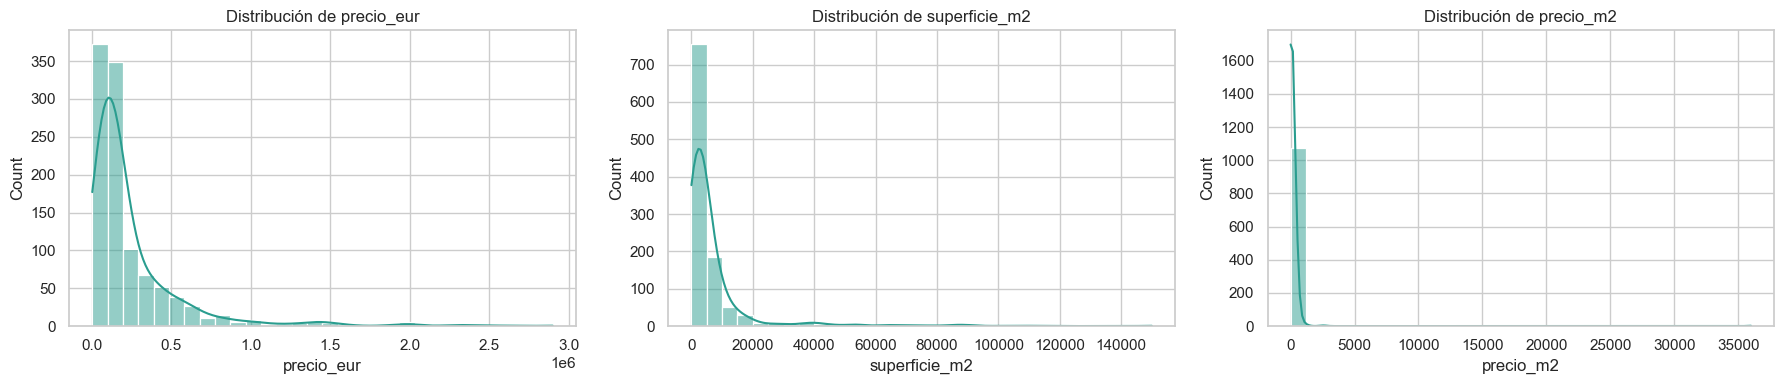

In [7]:
# Distribuciones principales
plot_cols = [c for c in ["precio_eur", "superficie_m2", "precio_m2"] if c in df.columns]

if plot_cols:
    fig, axes = plt.subplots(1, len(plot_cols), figsize=(6 * len(plot_cols), 4))
    if len(plot_cols) == 1:
        axes = [axes]

    for ax, col in zip(axes, plot_cols):
        sns.histplot(df[col].dropna(), kde=True, bins=30, ax=ax, color="#2a9d8f")
        ax.set_title(f"Distribución de {col}")
        ax.set_xlabel(col)

    plt.tight_layout()
    plt.show()

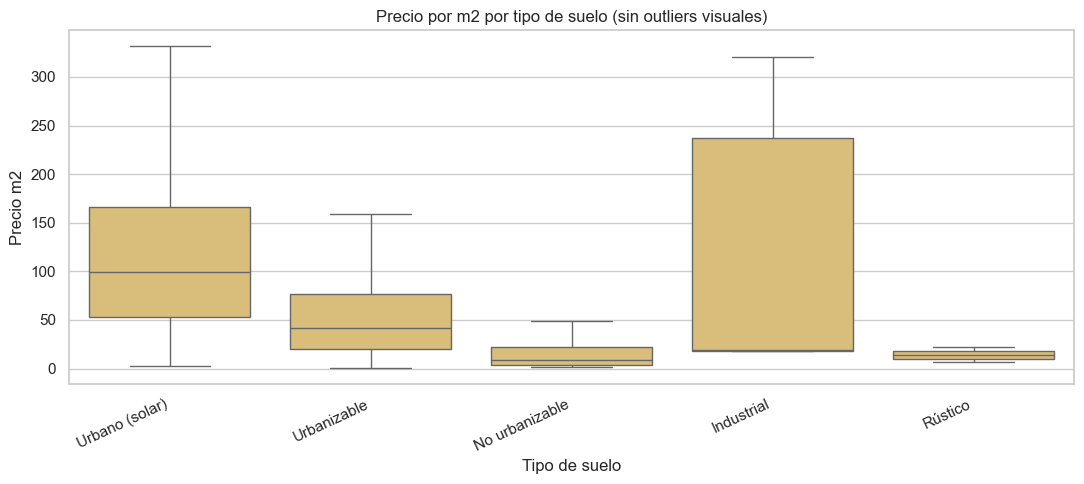

In [8]:
# Comparativa por tipo de suelo
if {"tipo_suelo", "precio_m2"}.issubset(df.columns):
    top_tipo = df["tipo_suelo"].value_counts(dropna=False).head(8).index
    data_box = df[df["tipo_suelo"].isin(top_tipo)].copy()

    plt.figure(figsize=(11, 5))
    sns.boxplot(data=data_box, x="tipo_suelo", y="precio_m2", showfliers=False, color="#e9c46a")
    plt.title("Precio por m2 por tipo de suelo (sin outliers visuales)")
    plt.xlabel("Tipo de suelo")
    plt.ylabel("Precio m2")
    plt.xticks(rotation=25, ha="right")
    plt.tight_layout()
    plt.show()

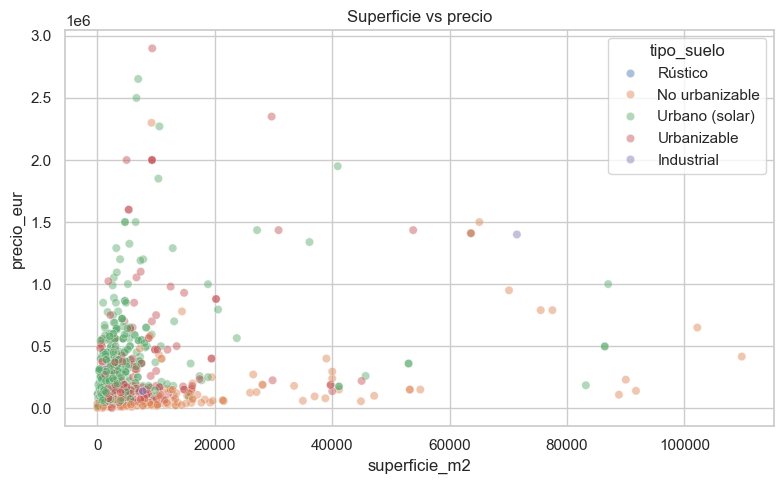

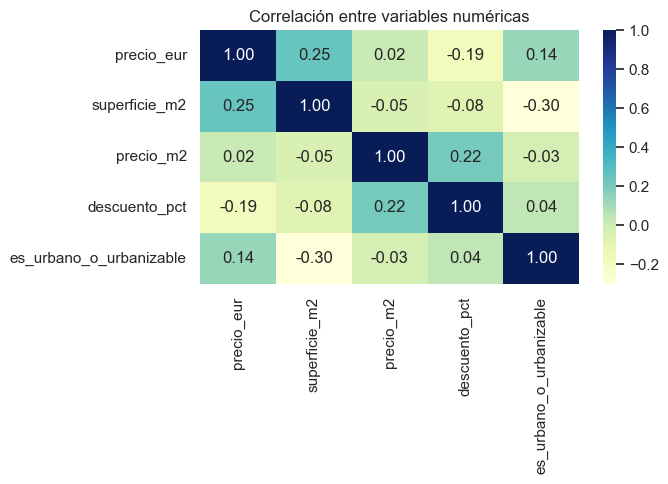

In [9]:
# Relación superficie-precio y correlación
if {"superficie_m2", "precio_eur"}.issubset(df.columns):
    plot_df = df[["superficie_m2", "precio_eur"] + (["tipo_suelo"] if "tipo_suelo" in df.columns else [])].dropna().copy()
    plot_df = plot_df[plot_df["superficie_m2"] > 0]

    plt.figure(figsize=(8, 5))
    sns.scatterplot(
        data=plot_df.sample(min(len(plot_df), 3000), random_state=42),
        x="superficie_m2",
        y="precio_eur",
        hue="tipo_suelo" if "tipo_suelo" in plot_df.columns else None,
        alpha=0.45
    )
    plt.title("Superficie vs precio")
    plt.tight_layout()
    plt.show()

corr_cols = [c for c in ["precio_eur", "superficie_m2", "precio_m2", "descuento_pct", "es_urbano_o_urbanizable"] if c in df.columns]
if len(corr_cols) >= 2:
    plt.figure(figsize=(7, 5))
    corr = df[corr_cols].corr(numeric_only=True)
    sns.heatmap(corr, annot=True, cmap="YlGnBu", fmt=".2f")
    plt.title("Correlación entre variables numéricas")
    plt.tight_layout()
    plt.show()

In [10]:
# Top registros para revisión rápida
if {"precio_m2", "titulo", "tipo_suelo"}.issubset(df.columns):
    top_precio_m2 = df.sort_values("precio_m2", ascending=False).head(10)[[
        "titulo", "tipo_suelo", "precio_eur", "superficie_m2", "precio_m2"
    ]]
    display(top_precio_m2)

,titulo,tipo_suelo,precio_eur,superficie_m2,precio_m2
854,"Calle Juncara, 1, Guarnizo",No urbanizable,36000,1.0,36000.000000
204,"Calle Alta, Centro - Ayuntamiento, Santander",Urbano (solar),115000,45.0,2555.555556
609,"Calle Alta, Santander",Urbano (solar),115000,45.0,2555.555556
903,"Calle Virgen del Campo, Cabezón de la Sal",Urbano (solar),190000,146.0,1301.369863
707,"Oruña, Piélagos",Urbano (solar),302800,267.0,1134.082397
59,"Calle Bolado, Monte, Santander",Urbanizable,485000,475.0,1021.052632
151,"Barrio Rinconeda, 1609, Polanco",Urbano (solar),545200,545.0,1000.366972
110,"Calle Macías Picavea, General Dávila, Santander",Urbano (solar),300000,324.0,925.925926
586,"Barrio la Sierra, 3, Liencres, Piélagos",Urbano (solar),315000,357.0,882.352941
181,"Barrio la Sierra, 3, Liencres, Piélagos",Urbano (solar),315000,357.0,882.352941
